# Data Cleaning & Feature Engineering
### Wind Turbine Physical Evolution: Bigger, Taller, More Powerful?

In this notebook I'm cleaning up the main dataset and building the engineered features I'll need for the EDA.

From the last notebook I already know:
- `t_cap`, `t_hh`, `t_rd`, `t_rsa` all have ~8% missing values
- `t_manu` has some missing values too
- Data types look mostly fine but I want to double check
- There might be some outliers in `t_cap`

Goal at the end of this notebook: save a clean version to `data/cleaned/wind_turbines_clean.csv`

**My null strategy (spoiler):** I'll drop rows only where `t_cap` or `p_year` is missing, keep other nulls in the base dataframe and filter per-analysis, and fill `t_manu` nulls with `'Unknown'`. More on this in Section 3.


## 1. Imports & Load Data

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')  # suppressing some pandas warnings that aren't helpful

plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

DATA_PATH = "../data/original/"

df = pd.read_csv(DATA_PATH + "wind-turbines.csv", encoding="latin1")
df_wind  = pd.read_csv(DATA_PATH + "windiest-states-in-the-us.-2025.csv", encoding="latin1")
df_rates = pd.read_csv(DATA_PATH + "average_electricity_rates.csv", encoding="latin1")

print(f"loaded turbines dataset: {df.shape[0]} rows, {df.shape[1]} columns")


loaded turbines dataset: 70808 rows, 27 columns


## 2. Fix Data Types

In [4]:
# most columns loaded fine but let me verify the ones I care about
print("dtypes for key columns:")
print(df[['p_year', 't_cap', 't_hh', 't_rd', 't_rsa', 't_manu', 't_state']].dtypes)


dtypes for key columns:
p_year     float64
t_cap      float64
t_hh       float64
t_rd       float64
t_rsa      float64
t_manu         str
t_state        str
dtype: object


In [5]:
# p_year should be integer but it loaded as float (because of some nulls)
# converting it — keeping as float for now so nulls don't cause issues
df['p_year'] = pd.to_numeric(df['p_year'], errors='coerce')

# same for the physical dimension columns
for col in ['t_cap', 't_hh', 't_rd', 't_rsa', 't_ttlh']:
    df[col] = pd.to_numeric(df[col], errors='coerce')

print("type conversion done!")


type conversion done!


## 3. Understanding & Handling Missing Values

Before I just blindly drop or fill nulls, I want to actually understand **why** they're missing.
That matters because the right strategy depends on what caused the null — not all missing values
should be treated the same way.


In [6]:
# first, let me see exactly how many nulls each key column has
key_cols = ['p_year', 't_cap', 't_hh', 't_rd', 't_rsa', 't_manu', 't_state']

null_counts = df[key_cols].isnull().sum()
null_pct    = (null_counts / len(df) * 100).round(1)

null_summary = pd.DataFrame({'null_count': null_counts, 'null_%': null_pct})
print("Missing values summary:")
print(null_summary)


Missing values summary:
         null_count  null_%
p_year          613     0.9
t_cap          5480     7.7
t_hh           6180     8.7
t_rd           5934     8.4
t_rsa          5934     8.4
t_manu         5640     8.0
t_state           0     0.0


### 3a. Why are these values missing?

Before deciding what to do, I need to ask: **is it random, or is there a pattern?**

Let me check whether the nulls cluster in specific decades — because if they do, that tells me
something about *why* the data is missing, not just *that* it's missing.


In [7]:
# adding a temporary decade column to investigate the null pattern
df['decade'] = (df['p_year'] // 10 * 10)

# where are the t_cap nulls coming from?
print("=== t_cap nulls by decade ===")
print(df[df['t_cap'].isna()]['decade'].value_counts().sort_index())
print()

# where are the t_hh / t_rd nulls coming from?
print("=== t_hh nulls by decade ===")
print(df[df['t_hh'].isna()]['decade'].value_counts().sort_index())
print()

# what year specifically are the 2020s nulls?
print("=== 2020s null t_cap — broken down by year ===")
print(df[(df['decade'] == 2020) & df['t_cap'].isna()]['p_year'].value_counts().sort_index())


=== t_cap nulls by decade ===
decade
1980.0    1459
1990.0     203
2000.0      65
2010.0     278
2020.0    2868
Name: count, dtype: int64

=== t_hh nulls by decade ===
decade
1980.0    2053
1990.0     214
2000.0      93
2010.0     313
2020.0    2899
Name: count, dtype: int64

=== 2020s null t_cap — broken down by year ===
p_year
2020.0     364
2021.0    2504
Name: count, dtype: int64


**What I found:**

The nulls are NOT random, they cluster in two very specific groups:

- **1980s turbines (~1,400–2,000 nulls):** These are old turbines from the very early days of 
  U.S. wind energy. Back then, physical specs like hub height and rotor diameter weren't 
  consistently documented. The data just doesn't exist — it was never recorded.

- **2021 turbines (~2,500 nulls):** These are brand-new installations. The database snapshot 
  was taken before all the specs were officially submitted. It's a data lag problem, 
  not a data quality problem.

This means the missingness is **not random**. It's tied to the age of the turbine.
This is important because it means I should NOT impute these values.
Imputing capacity for a 1980s turbine using the dataset average (~1,900 kW) would be
completely wrong, those turbines were 50–100 kW machines. I'd be making up data.


In [8]:
# let me also check: are the nulls in t_hh, t_rd, t_rsa all the SAME rows?
# if they are, that means one missing = all missing for that turbine

null_hh  = set(df[df['t_hh'].isna()].index)
null_rd  = set(df[df['t_rd'].isna()].index)
null_rsa = set(df[df['t_rsa'].isna()].index)
null_cap = set(df[df['t_cap'].isna()].index)

print("Rows missing ALL of t_hh, t_rd, and t_rsa:", len(null_hh & null_rd & null_rsa))
print("Rows missing t_hh but NOT t_cap:           ", len(null_hh - null_cap))
print("Rows missing t_rd but NOT t_cap:           ", len(null_rd - null_cap))
print()

# checking t_manu nulls separately
null_manu = set(df[df['t_manu'].isna()].index)
print("t_manu null rows that also have null t_cap:", len(null_manu & null_cap))
print("t_manu null rows that have a valid t_cap:  ", len(null_manu - null_cap))


Rows missing ALL of t_hh, t_rd, and t_rsa: 5932
Rows missing t_hh but NOT t_cap:            701
Rows missing t_rd but NOT t_cap:            455

t_manu null rows that also have null t_cap: 5463
t_manu null rows that have a valid t_cap:   177


**Key insight from the overlap check:**

- When `t_hh`, `t_rd`, and `t_rsa` are null, they're almost always null **together** on the same row.
  There's no point trying to recover one from the other.
- ~177 rows have a **valid `t_cap`** but a missing `t_manu`. These are useful for the capacity 
  trend analysis. I don't want to lose them. I'll handle them separately.

Now that I understand the nulls, here's my strategy for each column.


### 3b. Strategy: `t_cap` and `p_year` — Drop rows where these are null

**Why drop?**

`t_cap` is my **primary outcome variable** — it's the number I'm analyzing across every chart 
in the EDA. If I don't know a turbine's capacity, I literally cannot include it in the analysis.
There's no sensible value to fill in because:

- The 1980s nulls would get filled with ~1,900 kW (the dataset average) when they were actually 
  50–100 kW machines. That would completely distort the 1980s trend line.
- The 2021 nulls haven't been officially submitted yet — I'd be guessing at unreported specs.

Same logic for `p_year` — without knowing the install year I can't place a turbine in any decade,
which makes it useless for a time-series analysis.

I'm dropping ~5,500 rows here (~7.7% of the dataset), but I still keep 65,300+ turbines.
That's more than enough.


In [9]:
before = len(df)

# dropping ONLY where t_cap or p_year is null
# I'm NOT dropping rows with missing t_hh or t_rd here — those will be handled per-analysis
df_base = df.dropna(subset=['t_cap', 'p_year']).copy()

after = len(df_base)
dropped = before - after

print(f"rows before: {before:,}")
print(f"rows dropped (null t_cap or p_year): {dropped:,}  ({dropped/before*100:.1f}%)")
print(f"rows remaining: {after:,}")
print()

# confirming the decades still look reasonable after the drop
print("turbines per decade after drop:")
print(df_base['decade'].value_counts().sort_index())


rows before: 70,808
rows dropped (null t_cap or p_year): 5,486  (7.7%)
rows remaining: 65,322

turbines per decade after drop:
decade
1980.0     1307
1990.0      880
2000.0    20762
2010.0    33936
2020.0     8437
Name: count, dtype: int64


### 3c. Strategy: `t_hh` and `t_rd` — Keep nulls in base dataframe, filter per analysis

**Why NOT drop globally?**

`t_hh` (hub height) and `t_rd` (rotor diameter) are supporting physical dimensions.
Not every chart in my EDA needs both of them at the same time.

- For **Part 1 (capacity trend)** — I only need `t_cap` and `p_year`. Dropping rows with 
  missing `t_hh` would unnecessarily reduce my sample size for that chart.
- For **Part 2 (correlation)** — I do need all physical dimensions together, so I'll apply 
  a targeted filter there, only for that section.

The strategy: keep `df_base` as-is, and apply `dropna(subset=[...])` **inside each analysis 
section** based on what that specific chart actually needs. This way I'm never losing rows 
for a reason that doesn't apply to what I'm doing.


In [10]:
# just confirming how many rows each part of the EDA will work with
# this is useful to report so the reader knows the sample size per chart

p1_rows  = df_base.dropna(subset=['t_cap', 'p_year'])
p1b_rows = df_base.dropna(subset=['t_hh',  'p_year'])
p1c_rows = df_base.dropna(subset=['t_rd',  'p_year'])
p2_rows  = df_base.dropna(subset=['t_cap', 't_hh', 't_rd', 't_rsa'])
p5_rows  = df_base.dropna(subset=['t_cap', 't_rsa', 'p_year'])

print("Usable rows per EDA section:")
print(f"  Part 1 — Capacity trend (t_cap + p_year):          {len(p1_rows):,}")
print(f"  Part 1b — Hub height trend (t_hh + p_year):        {len(p1b_rows):,}")
print(f"  Part 1c — Rotor diameter trend (t_rd + p_year):    {len(p1c_rows):,}")
print(f"  Part 2 — Correlation (all 4 physical dims):        {len(p2_rows):,}")
print(f"  Part 3 — Manufacturer (t_cap + t_manu + p_year):   filters applied in EDA nb")
print(f"  Part 4 — Geographic (t_cap + t_state):             {len(p1_rows):,}  (t_state has 0 nulls)")
print(f"  Part 5 — Specific power (t_cap + t_rsa + p_year):  {len(p5_rows):,}")


Usable rows per EDA section:
  Part 1 — Capacity trend (t_cap + p_year):          65,322
  Part 1b — Hub height trend (t_hh + p_year):        64,622
  Part 1c — Rotor diameter trend (t_rd + p_year):    64,867
  Part 2 — Correlation (all 4 physical dims):        64,620
  Part 3 — Manufacturer (t_cap + t_manu + p_year):   filters applied in EDA nb
  Part 4 — Geographic (t_cap + t_state):             65,322  (t_state has 0 nulls)
  Part 5 — Specific power (t_cap + t_rsa + p_year):  64,867


### 3d. Strategy: `t_manu` — Fill nulls with `'Unknown'`

**Why fill instead of drop?**

~177 rows have a valid `t_cap` but a missing `t_manu`. These rows are perfectly usable for:
- Decade-level capacity trends (Part 1)
- Geographic analysis (Part 4)
- Specific power trends (Part 5)

The only section where manufacturer matters is Part 3. There, I'll filter out `'Unknown'` 
rows when building the manufacturer chart — but I don't want to lose those 177 rows from 
every other chart just because one chart doesn't need them.

Filling with `'Unknown'` is the cleanest way to keep the rows available everywhere and 
simply exclude the label where it's not meaningful.


In [11]:
# checking how many rows this affects
manu_nulls = df_base['t_manu'].isna().sum()
print(f"rows with null t_manu (but valid t_cap): {manu_nulls}")
print()

# filling nulls with 'Unknown'
df_base['t_manu'] = df_base['t_manu'].fillna('Unknown')

# confirming
print("t_manu nulls after fill:", df_base['t_manu'].isna().sum())
print()
print("top manufacturers (including Unknown):")
print(df_base['t_manu'].value_counts().head(8))


rows with null t_manu (but valid t_cap): 175

t_manu nulls after fill: 0

top manufacturers (including Unknown):
t_manu
GE Wind                            29131
Vestas                             16259
Siemens                             5035
Gamesa                              3077
Mitsubishi                          2620
Siemens Gamesa Renewable Energy     2033
Nordex                              1591
Suzlon                              1316
Name: count, dtype: int64


### 3e. Final null check

Let me do one last check to confirm the state of the dataset before I move on to 
feature engineering.


In [12]:
# final null summary for key columns
key_cols = ['p_year', 't_cap', 't_hh', 't_rd', 't_rsa', 't_manu', 't_state']

null_after = df_base[key_cols].isnull().sum()
null_pct_after = (null_after / len(df_base) * 100).round(1)

summary = pd.DataFrame({
    'remaining_nulls': null_after,
    'null_%': null_pct_after,
    'action_taken': [
        'dropped rows', 'dropped rows', 
        'kept — filter per analysis', 'kept — filter per analysis',
        'kept — filter per analysis', "filled with 'Unknown'",
        'no nulls (clean)'
    ]
})

print("Null handling summary:")
print(summary)
print()
print(f"Final base dataset: {df_base.shape[0]:,} rows x {df_base.shape[1]} columns")


Null handling summary:
         remaining_nulls  null_%                action_taken
p_year                 0     0.0                dropped rows
t_cap                  0     0.0                dropped rows
t_hh                 700     1.1  kept — filter per analysis
t_rd                 455     0.7  kept — filter per analysis
t_rsa                455     0.7  kept — filter per analysis
t_manu                 0     0.0       filled with 'Unknown'
t_state                0     0.0            no nulls (clean)

Final base dataset: 65,322 rows x 28 columns


## 4. Check for Outliers

In [13]:
# looking at the min/max for capacity and physical dimensions
# I want to flag anything that seems unrealistic

print("t_cap stats:")
print(df_base['t_cap'].describe())
print()
print("t_hh stats:")
print(df_base['t_hh'].describe())
print()
print("t_rd stats:")
print(df_base['t_rd'].describe())


t_cap stats:
count    65322.000000
mean      1963.686032
std        716.922684
min         50.000000
25%       1500.000000
50%       2000.000000
75%       2300.000000
max       6000.000000
Name: t_cap, dtype: float64

t_hh stats:
count    64622.000000
mean        81.059327
std         12.018904
min         22.800000
25%         80.000000
50%         80.000000
75%         87.000000
max        131.000000
Name: t_hh, dtype: float64

t_rd stats:
count    64867.000000
mean        95.671121
std         23.414479
min         13.400000
25%         82.000000
50%        100.000000
75%        110.000000
max        155.000000
Name: t_rd, dtype: float64


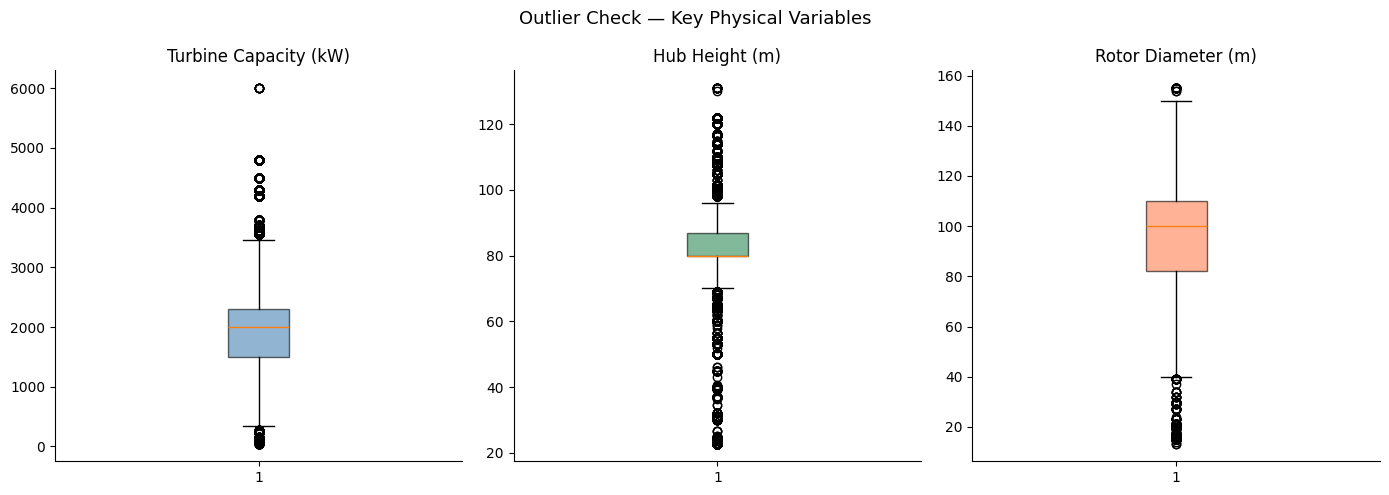

In [14]:
# plotting boxplots to visually spot outliers

fig, axes = plt.subplots(1, 3, figsize=(14, 5))

axes[0].boxplot(df_base['t_cap'].dropna(), vert=True, patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.6))
axes[0].set_title("Turbine Capacity (kW)")

axes[1].boxplot(df_base['t_hh'].dropna(), vert=True, patch_artist=True,
                boxprops=dict(facecolor='seagreen', alpha=0.6))
axes[1].set_title("Hub Height (m)")

axes[2].boxplot(df_base['t_rd'].dropna(), vert=True, patch_artist=True,
                boxprops=dict(facecolor='coral', alpha=0.6))
axes[2].set_title("Rotor Diameter (m)")

plt.suptitle("Outlier Check — Key Physical Variables", fontsize=13)
plt.tight_layout()
plt.show()


In [16]:
# flagging extreme values just to see who they are
# not removing them yet, just want to know what they are

print("turbines with t_cap >= 5000 kW:")
print(df_base[df_base['t_cap'] >= 5000][['p_name', 't_state', 't_manu', 't_model', 't_cap', 'p_year']].head(10))


turbines with t_cap >= 5000 kW:
                               p_name t_state  \
5149                     Block Island      RI   
5150                     Block Island      RI   
5151                     Block Island      RI   
5152                     Block Island      RI   
5153                     Block Island      RI   
13143  Coastal Virginia Offshore Wind      VA   
13144  Coastal Virginia Offshore Wind      VA   

                                t_manu        t_model   t_cap  p_year  
5149                           GE Wind  Haliade 150-6  6000.0  2016.0  
5150                           GE Wind  Haliade 150-6  6000.0  2016.0  
5151                           GE Wind  Haliade 150-6  6000.0  2016.0  
5152                           GE Wind  Haliade 150-6  6000.0  2016.0  
5153                           GE Wind  Haliade 150-6  6000.0  2016.0  
13143  Siemens Gamesa Renewable Energy    SWT-6.0-154  6000.0  2021.0  
13144  Siemens Gamesa Renewable Energy    SWT-6.0-154  6000.0  2021.0  

In [17]:
# also checking the very small ones (sub-100 kW) these are likely 1980s era turbines
print("turbines with t_cap < 100 kW:")
print(df_base[df_base['t_cap'] < 100][['p_name', 't_state', 't_manu', 't_cap', 'p_year']].head(10))


turbines with t_cap < 100 kW:
                  p_name t_state         t_manu  t_cap  p_year
0               251 Wind      CA         Vestas   95.0  1987.0
1               251 Wind      CA         Vestas   95.0  1987.0
2               251 Wind      CA         Vestas   95.0  1987.0
2001     Aurora Wal-Mart      CO  Bergey Energy   50.0  2005.0
2273            BTI Wind      KS      Endurance   50.0  2010.0
16512        Dynapower 1      VT            AOC   50.0  1997.0
23641  H & S - Tehachapi      CA         Vestas   90.0  1985.0
23642  H & S - Tehachapi      CA         Vestas   90.0  1985.0
23643  H & S - Tehachapi      CA         Vestas   90.0  1985.0
23644  H & S - Tehachapi      CA         Vestas   90.0  1985.0


In [19]:
# I'll keep everything for now since both extremes seem to be real turbines
# just old or experimental ones, not data errors
print("keeping all rows, no outliers removed, just flagged")
print(f"final dataset size: {df_base.shape}")


keeping all rows, no outliers removed, just flagged
final dataset size: (65322, 28)


## 5. Feature Engineering

### 5a. `decade` — Installation decade

In [20]:
# binning p_year into decades so I can do decade-level trend analysis
# using integer division: e.g. 2007 // 10 * 10 = 2000

df_base['decade'] = (df_base['p_year'] // 10 * 10).astype(int)

print("turbines per decade:")
print(df_base['decade'].value_counts().sort_index())


turbines per decade:
decade
1980     1307
1990      880
2000    20762
2010    33936
2020     8437
Name: count, dtype: int64


### 5b. `capacity_tier` — Size category

In [21]:
# grouping turbines into 4 size buckets
# this will help me show how the MIX of turbine sizes changed over time

bins   = [0, 999, 1999, 2999, 10000]
labels = ['sub-MW (<1000 kW)', 'mid (1000-1999 kW)', 'large (2000-2999 kW)', 'utility (3000+ kW)']

df_base['capacity_tier'] = pd.cut(df_base['t_cap'], bins=bins, labels=labels)

print("turbines per capacity tier:")
print(df_base['capacity_tier'].value_counts())


turbines per capacity tier:
capacity_tier
large (2000-2999 kW)    29078
mid (1000-1999 kW)      26661
utility (3000+ kW)       5239
sub-MW (<1000 kW)        4344
Name: count, dtype: int64


### 5c. `specific_power` — Efficiency proxy (W/m²)

In [22]:
# specific power = capacity / rotor swept area
# this tells us whether capacity grew because of bigger rotors or better technology
# lower specific power = rotors grew faster than capacity (optimizing for low wind sites)

df_base['specific_power'] = (df_base['t_cap'] * 1000) / df_base['t_rsa']  # converting kW to W first

print("specific power stats (W/m2):")
print(df_base['specific_power'].describe().round(2))


specific power stats (W/m2):
count    64867.00
mean       278.19
std         61.44
min        176.84
25%        222.61
50%        269.15
75%        322.12
max        795.77
Name: specific_power, dtype: float64


### 5d. `fleet_age_index` — Average install year per state

In [23]:
# this gives me a single number per state representing how 'modern' its fleet is
# higher = more recently built turbines on average

fleet_age = df_base.groupby('t_state')['p_year'].mean().round(1).reset_index()
fleet_age.columns = ['t_state', 'fleet_age_index']

# merging back into main df_base
df_base = df_base.merge(fleet_age, on='t_state', how='left')

print("fleet age index (avg install year) by state — bottom 10 (oldest fleets):")
print(fleet_age.sort_values('fleet_age_index').head(10))


fleet age index (avg install year) by state — bottom 10 (oldest fleets):
   t_state  fleet_age_index
3       CA           2002.0
1       AR           2003.0
36      TN           2003.3
25      NJ           2006.2
41      WA           2008.1
0       AK           2008.4
31      OR           2008.9
42      WI           2009.2
32      PA           2009.6
28      NY           2009.6


## 6. Final Check Before Saving

In [24]:
# quick sanity check on all the new columns

print("new engineered columns:")
print(df_base[['decade', 'capacity_tier', 'specific_power', 'fleet_age_index']].head(5))
print()
print("null counts in engineered columns:")
print(df_base[['decade', 'capacity_tier', 'specific_power', 'fleet_age_index']].isnull().sum())


new engineered columns:
   decade       capacity_tier  specific_power  fleet_age_index
0    1980   sub-MW (<1000 kW)             NaN           2002.0
1    1980   sub-MW (<1000 kW)             NaN           2002.0
2    1980   sub-MW (<1000 kW)             NaN           2002.0
3    2010  utility (3000+ kW)      244.461919           2012.3
4    2010  utility (3000+ kW)      244.461919           2012.3

null counts in engineered columns:
decade               0
capacity_tier        0
specific_power     455
fleet_age_index      0
dtype: int64


In [25]:
# final shape
print(f"final cleaned dataset: {df_base.shape[0]} rows, {df_base.shape[1]} columns")
print()
print("all columns in cleaned dataset:")
print(list(df_base.columns))


final cleaned dataset: 65322 rows, 31 columns

all columns in cleaned dataset:
['case_id', 'faa_ors', 'faa_asn', 'usgs_pr_id', 'eia_id', 't_state', 't_county', 't_fips', 'p_name', 'p_year', 'p_tnum', 'p_cap', 't_manu', 't_model', 't_cap', 't_hh', 't_rd', 't_rsa', 't_ttlh', 'retrofit', 'retrofit_year', 't_conf_atr', 't_conf_loc', 't_img_date', 't_img_srce', 'xlong', 'ylat', 'decade', 'capacity_tier', 'specific_power', 'fleet_age_index']


## 7. Save Cleaned Dataset

In [26]:
import os

# making sure the output folder exists
os.makedirs("../data/cleaned", exist_ok=True)

# saving the cleaned file
df_base.to_csv("../data/cleaned/wind_turbines_clean.csv", index=False)

print("saved to ../data/cleaned/wind_turbines_clean.csv")


saved to ../data/cleaned/wind_turbines_clean.csv


## 8. Summary

Here's what I did in this notebook:

- Fixed data types for all numeric columns
- Investigated **why** values were missing before deciding what to do about them
  - 1980s nulls = old turbines, specs were never recorded historically
  - 2021 nulls = data lag, specs not yet submitted when the DB snapshot was taken
- **Dropped** ~5,500 rows where `t_cap` or `p_year` was null (~7.7%) — can't impute the primary outcome variable
- **Kept** `t_hh`, `t_rd`, `t_rsa` nulls in the base dataframe — these will be filtered per-analysis section in the EDA notebook depending on what each chart needs
- **Filled** `t_manu` nulls with `'Unknown'` to preserve 177 rows that are useful for non-manufacturer charts
- Created 4 engineered features:
  - `decade` — groups turbines by install decade
  - `capacity_tier` — groups turbines into 4 size buckets
  - `specific_power` — W/m² efficiency proxy
  - `fleet_age_index` — average install year per state

**Next:** `03_EDA.ipynb` — actual analysis and visualizations
